# Статистический анализ факторов академической успеваемости

Этот проект представляет собой аналитическое исследование данных об успеваемости студентов ВШЭ по микроэкономике и макроэкономике. Цель работы — не просто описать распределения оценок, а проверить, какие факторы статистически связаны с итоговыми результатами экзаменов.

В анализе используются данные по учебным группам, преподавателям, семестровой активности, летучкам, контрольным работам, экзаменам и образовательной скидке при поступлении. На основе этих данных проводится полный цикл статистического анализа: предобработка, описательная статистика, визуализация распределений, проверка предпосылок и тестирование гипотез.

Основной фокус проекта — применение статистических критериев и корректная интерпретация результатов. В работе используются параметрические и непараметрические методы: **ANOVA, Welch ANOVA, критерий Краскала–Уоллиса, t-test, корреляции Pearson, Spearman и Kendall**, а также поправка на множественные проверки.

Ключевая задача — показать, какие связи в данных являются статистически значимыми, какие эффекты остаются только описательными, а какие выводы можно считать устойчивыми с учётом структуры данных и ограничений выборки.


## Что показывает этот ноутбук

| Блок навыков | Что сделано в анализе |
|---|---|
| Подготовка данных | загрузка, проверка пропусков, анонимизация, нормализация разных шкал активности |
| EDA | распределения, выбросы, структура групп, описательная статистика |
| Проверка предпосылок | нормальность, равенство дисперсий, выбор параметрических / непараметрических методов |
| Статистические критерии | ANOVA, Welch t-test, Kruskal-Wallis, Spearman, Kendall, Pearson |
| Работа с множественными проверками | Benjamini-Hochberg FDR для недельных корреляций |
| Интерпретация | p-value, размер эффекта, сила корреляции, практический смысл результата |


In [2]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

ALPHA = 0.05


def p_format(p):
    if pd.isna(p):
        return "NA"
    return "<0.001" if p < 0.001 else f"{p:.3f}"


def corr_strength(r):
    if pd.isna(r):
        return "недостаточно данных"
    a = abs(r)
    if a < 0.10:
        return "нет/очень слабая"
    if a < 0.30:
        return "слабая"
    if a < 0.50:
        return "умеренная"
    if a < 0.70:
        return "сильная"
    return "очень сильная"


def numbered_cols(data, prefix):
    cols = [c for c in data.columns if re.fullmatch(fr"{prefix}_\d+", c)]
    return sorted(cols, key=lambda x: int(x.split("_")[-1]))


def corr_row(data, x, y, label):
    pair = data[[x, y]].dropna()
    if len(pair) < 3 or pair[x].nunique() < 2 or pair[y].nunique() < 2:
        return {"Показатель": label, "N": len(pair)}
    rho, ps = stats.spearmanr(pair[x], pair[y])
    tau, pk = stats.kendalltau(pair[x], pair[y])
    r, pp = stats.pearsonr(pair[x], pair[y])
    return {
        "Показатель": label,
        "N": len(pair),
        "Spearman rho": rho,
        "Spearman p": ps,
        "Pearson r": r,
        "Pearson p": pp,
        "Kendall tau": tau,
        "Kendall p": pk,
        "Сила связи": corr_strength(rho),
    }


def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    mask = ~np.isnan(p)
    p_valid = p[mask]
    if len(p_valid) == 0:
        return out
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    original = np.empty_like(adjusted)
    original[order] = adjusted
    out[mask] = original
    return out


# 1. Загрузка и подготовка данных

Цель подготовки — привести данные к формату, пригодному для статистических тестов:

- не использовать ФИО в анализе;
- проверить пропуски в ключевых метриках;
- нормализовать семинарскую активность, потому что у преподавателей разные шкалы: `0–4` и `0–3`;
- привести летучки к шкале `0–1` через деление на 6;
- собрать агрегированные показатели активности по каждому предмету.


In [3]:
df_raw = pd.read_excel(io.BytesIO(DATA_BYTES))

# ФИО не нужны для статистического анализа и не выводятся в ноутбуке.
df = df_raw.drop(columns=["name"], errors="ignore").copy()

sem_micro_cols = numbered_cols(df, "sem_micro")
let_micro_cols = numbered_cols(df, "let_micro")
sem_macro_cols = numbered_cols(df, "sem_macro")
let_macro_cols = numbered_cols(df, "let_macro")

scale_by_teacher = df["teacher"].map({0: 4, 1: 3}).astype(float)

# Нормализация семинарской активности по шкале конкретного преподавателя.
df["sem_micro_norm"] = df[sem_micro_cols].div(scale_by_teacher, axis=0).mean(axis=1)
df["sem_macro_norm"] = df[sem_macro_cols].div(scale_by_teacher, axis=0).mean(axis=1)

# Летучки: шкала 0–6, поэтому делим средний балл на 6.
df["let_micro_mean"] = df[let_micro_cols].mean(axis=1)
df["let_macro_mean"] = df[let_macro_cols].mean(axis=1)

# Итоговая активность = среднее между нормированной семинарской активностью и нормированными летучками.
df["activity_micro"] = (df["sem_micro_norm"] + df["let_micro_mean"] / 6) / 2
df["activity_macro"] = (df["sem_macro_norm"] + df["let_macro_mean"] / 6) / 2

# Для сравнения контрольных по предметам: две микро-КР агрегируются в один показатель.
df["test_micro_avg"] = df[["test1_micro_res", "test2_micro_res"]].mean(axis=1)

print(f"Размер исходного датасета: {df_raw.shape[0]} строк × {df_raw.shape[1]} колонок")
print(f"Размер рабочего датасета после исключения ФИО: {df.shape[0]} строк × {df.shape[1]} колонок")
print(f"Недельные переменные: micro sem={len(sem_micro_cols)}, micro let={len(let_micro_cols)}, macro sem={len(sem_macro_cols)}, macro let={len(let_macro_cols)}")

display(df.head())


Размер исходного датасета: 155 строк × 91 колонок
Размер рабочего датасета после исключения ФИО: 155 строк × 97 колонок
Недельные переменные: micro sem=13, micro let=11, macro sem=16, macro let=15


,id,group,discount,teacher,sem_micro_1,sem_micro_2,sem_micro_3,sem_micro_4,sem_micro_5,sem_micro_6,sem_micro_7,sem_micro_8,sem_micro_9,sem_micro_10,sem_micro_11,sem_micro_12,sem_micro_13,let_micro_1,let_micro_2,let_micro_3,let_micro_4,let_micro_5,let_micro_6,let_micro_7,let_micro_8,let_micro_9,let_micro_10,let_micro_11,test1_micro_1,test1_micro_2,test1_micro_3,test1_micro_4,test1_micro_5,test1_micro_res,test2_micro_1,test2_micro_2,test2_micro_3,test2_micro_4,test2_micro_5,test2_micro_res,exam_micro_1,exam_micro_2,exam_micro_3,exam_micro_4,exam_micro_5,exam_micro_res,sem_macro_1,sem_macro_2,sem_macro_3,sem_macro_4,sem_macro_5,sem_macro_6,sem_macro_7,sem_macro_8,sem_macro_9,sem_macro_10,sem_macro_11,sem_macro_12,sem_macro_13,sem_macro_14,sem_macro_15,sem_macro_16,let_macro_1,let_macro_2,let_macro_3,let_macro_4,let_macro_5,let_macro_6,let_macro_7,let_macro_8,let_macro_9,let_macro_10,let_macro_11,let_macro_12,let_macro_13,let_macro_14,let_macro_15,test_macro_A,test_macro_B,test_macro_C1,test_macro_C2,test_macro_res,exam_macro_A,exam_macro_B1,exam_macro_B2,exam_macro_B3,exam_macro_B4,exam_macro_C1,exam_macro_C2,exam_macro_res,sem_micro_norm,sem_macro_norm,let_micro_mean,let_macro_mean,activity_micro,activity_macro,test_micro_avg
0,1,4,75.0000,0,2.0000,2,2,3.0000,4,4,4,4,4,4,4,4,3,6.0000,5.0000,4.5000,6.0000,4.0000,6.0000,6.0000,6.0000,4.0000,6.0000,6.0000,20.0000,20.0000,0.0000,20.0000,16.0000,76.0000,16.0000,1.0000,12.0000,4.0000,11.0000,44.0000,16.0000,3.0000,12.0000,15.0000,0.0000,46.0000,4,4,4,3,4,4,4,4,4,4,4,4,4,4,4,4,4.5000,6.0000,6.0000,6.0000,6.0000,0.5000,6.0000,5.0000,4.5000,4.0000,5.0000,5.0000,6.0000,4.5000,6.0000,7.0000,14.0000,9.0000,0.0000,30.0000,16.0000,0.0000,8.0000,0.0000,2.0000,7.0000,3.0000,36.0000,0.8462,0.9844,5.4091,5.0000,0.8738,0.9089,60.0000
1,2,4,75.0000,0,2.0000,1,1,0.0000,1,1,2,3,3,1,1,0,1,6.0000,6.0000,3.0000,6.0000,6.0000,6.0000,6.0000,6.0000,1.0000,3.0000,4.0000,18.0000,18.0000,5.0000,6.0000,8.0000,55.0000,14.0000,10.0000,15.0000,0.0000,29.0000,68.0000,19.0000,0.0000,11.0000,13.0000,7.0000,50.0000,4,1,1,1,1,1,1,1,1,1,2,1,1,1,4,4,4.5000,5.5000,6.0000,6.0000,6.0000,1.0000,3.0000,3.0000,2.5000,6.0000,5.0000,5.0000,5.0000,2.0000,6.0000,11.0000,11.0000,0.0000,0.0000,22.0000,16.0000,0.0000,10.0000,0.0000,0.0000,11.0000,0.0000,37.0000,0.3269,0.4062,4.8182,4.4333,0.5650,0.5726,61.5000
2,3,4,100.0000,0,0.0000,1,2,4.0000,4,4,2,1,4,4,0,1,4,6.0000,5.0000,4.0000,6.0000,6.0000,6.0000,6.0000,6.0000,0.0000,5.5000,4.5000,19.0000,17.0000,0.0000,19.0000,16.0000,71.0000,12.0000,0.0000,15.0000,16.0000,18.0000,61.0000,15.0000,3.0000,12.0000,13.0000,13.0000,56.0000,1,0,4,3,4,4,4,4,4,4,4,4,4,4,4,4,2.0000,1.0000,4.5000,6.0000,6.0000,0.0000,5.0000,6.0000,4.5000,6.0000,5.0000,5.0000,6.0000,5.5000,NaN,14.0000,24.0000,8.0000,0.0000,46.0000,12.0000,3.0000,2.0000,0.0000,0.0000,8.0000,10.0000,35.0000,0.5962,0.8750,5.0000,4.4643,0.7147,0.8095,66.0000
3,4,4,50.0000,0,3.0000,2,1,0.0000,1,1,1,1,1,1,1,0,0,6.0000,5.0000,3.5000,4.0000,5.5000,NaN,6.0000,3.0000,0.0000,4.0000,4.0000,16.0000,12.0000,6.0000,8.0000,10.0000,52.0000,10.0000,0.0000,12.0000,1.0000,5.0000,28.0000,14.0000,7.0000,7.0000,7.0000,0.0000,35.0000,0,4,3,1,1,1,1,1,1,0,4,1,1,1,4,4,0.5000,5.0000,6.0000,NaN,1.5000,NaN,0.5000,3.0000,6.0000,6.0000,4.5000,5.0000,6.0000,1.0000,6.0000,6.0000,21.0000,0.0000,0.0000,27.0000,8.0000,2.0000,0.0000,0.0000,2.0000,0.0000,0.0000,12.0000,0.2500,0.4375,4.1000,3.9231,0.4667,0.5457,40.0000
4,5,4,50.0000,0,3.0000,1,2,1.0000,1,1,3,3,3,3,4,4,0,2.0000,5.0000,3.5000,4.0000,3.0000,6.0000,6.0000,6.0000,1.0000,0.0000,4.5000,10.0000,12.0000,0.0000,16.0000,5.0000,43.0000,12.0000,0.0000,11.0000,0.0000,3.0000,26.0000,11.0000,0.0000,5.0000,9.0000,0.0000,25.0000,2,2,1,0,1,1,1,1,1,1,1,1,1,1,1,1,4.0000,1.5000,4.0000,NaN,6.0000,0.5000,4.0000,2.0000,4.5000,4.0000,4.0000,5.0000,5.0000,3.0000,3.0000,12.0000,2.0000,0.0000,0.0000,14.0000,4.0000,2.0000,2.0000,0.0000,0.0000,0.0000,22.0000,30.0000,0.5577,0.2656,3.7273,3.6071,0.5895,0.4334,34.5000


In [4]:
key_cols = [
    "group", "teacher", "discount",
    "exam_micro_res", "exam_macro_res",
    "test1_micro_res", "test2_micro_res", "test_macro_res",
    "activity_micro", "activity_macro",
]

quality = pd.DataFrame({
    "non_null": df[key_cols].notna().sum(),
    "missing": df[key_cols].isna().sum(),
    "missing_%": df[key_cols].isna().mean() * 100,
}).sort_values("missing_%", ascending=False)

display(quality.round(2))


,non_null,missing,missing_%
test_macro_res,130,25,16.1300
discount,133,22,14.1900
exam_macro_res,142,13,8.3900
test2_micro_res,147,8,5.1600
exam_micro_res,149,6,3.8700
test1_micro_res,151,4,2.5800
activity_micro,153,2,1.2900
activity_macro,154,1,0.6500
teacher,155,0,0.0000
group,155,0,0.0000


## Ключевые решения по обработке

| Проблема в данных | Решение |
|---|---|
| Разные шкалы семинарской активности | нормализация по максимуму шкалы преподавателя |
| Пропуски в экзаменах и контрольных | исключение только из конкретного теста, без замены нулями |
| Порядковая природа скидки | основной метод для связей — Spearman / Kendall, не только Pearson |
| Много недельных проверок H5 | FDR-поправка Benjamini-Hochberg |


# 2. EDA: распределения, выбросы, структура выборки


In [5]:
numeric_vars = [
    "discount", "exam_micro_res", "exam_macro_res",
    "test1_micro_res", "test2_micro_res", "test_macro_res",
    "activity_micro", "activity_macro",
]

desc_rows = []
for col in numeric_vars:
    s = df[col].dropna()
    desc_rows.append({
        "variable": col,
        "N": int(s.count()),
        "missing": int(df[col].isna().sum()),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "max": s.max(),
        "skew": s.skew(),
        "kurtosis": s.kurtosis(),
    })

desc = pd.DataFrame(desc_rows)
display(desc.round(3))


,variable,N,missing,mean,median,std,min,Q1,Q3,max,skew,kurtosis
0,discount,133,22,64.4740,75.0000,34.5710,0.0000,50.0000,100.0000,100.0000,-0.4980,-0.9820
1,exam_micro_res,149,6,44.5700,44.0000,14.1000,10.0000,35.0000,55.0000,80.0000,-0.0230,-0.0890
2,exam_macro_res,142,13,24.4230,23.5000,11.5360,0.0000,17.0000,32.0000,59.0000,0.1590,0.1160
3,test1_micro_res,151,4,60.2780,61.0000,17.0940,20.0000,46.5000,72.0000,94.0000,-0.1260,-0.7890
4,test2_micro_res,147,8,42.4080,40.0000,24.4120,0.0000,23.5000,61.0000,96.0000,0.2540,-0.7930
5,test_macro_res,130,25,27.0310,26.0000,13.5620,0.0000,17.0000,34.7500,69.0000,0.5830,0.3030
6,activity_micro,153,2,0.5570,0.5640,0.1500,0.1200,0.4500,0.6490,0.9430,-0.1310,-0.2680
7,activity_macro,154,1,0.5910,0.5900,0.1800,0.0000,0.4830,0.7370,0.9190,-0.6170,0.7550


In [6]:
group_structure = df.groupby("group").agg(
    n=("id", "count"),
    mean_discount=("discount", "mean"),
    exam_micro_mean=("exam_micro_res", "mean"),
    exam_macro_mean=("exam_macro_res", "mean"),
    activity_micro_mean=("activity_micro", "mean"),
    activity_macro_mean=("activity_macro", "mean"),
).round(3)

display(group_structure)


,n,mean_discount,exam_micro_mean,exam_macro_mean,activity_micro_mean,activity_macro_mean
group,,,,,,
1,31,64.2860,44.7780,22.3000,0.5170,0.6110
2,28,55.7690,45.4290,26.5380,0.4990,0.5840
3,33,73.0000,41.5810,23.1430,0.6190,0.5760
4,31,67.7080,47.2900,27.1430,0.5520,0.5720
5,32,62.5000,43.9060,23.3670,0.5870,0.6090


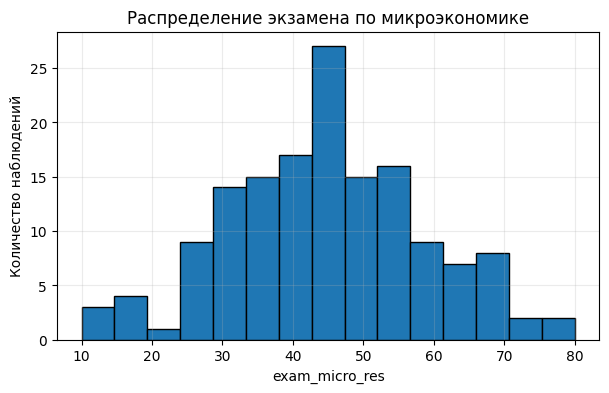

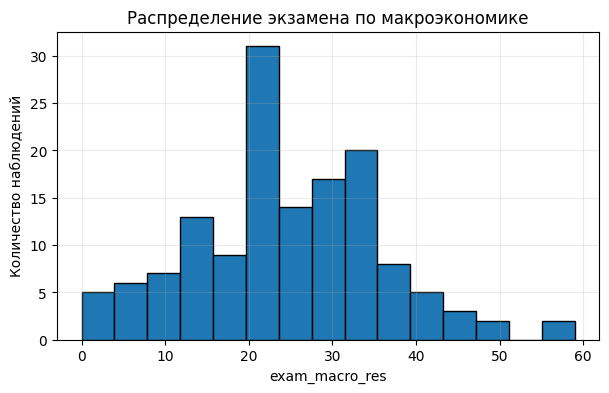

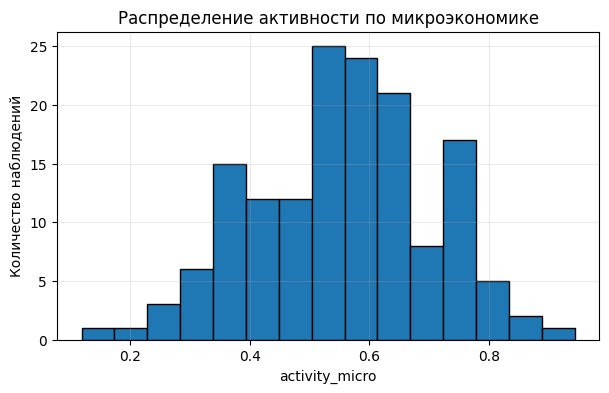

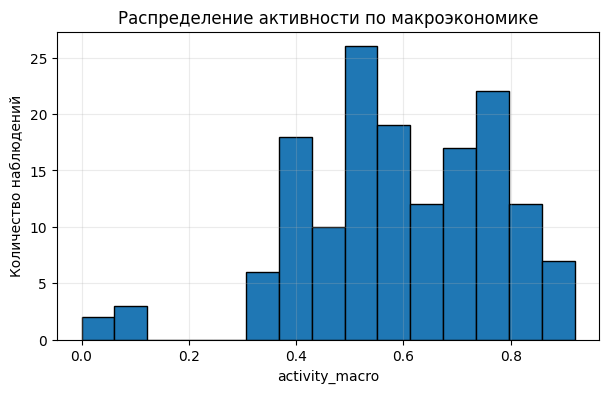

In [7]:
for col, title in [
    ("exam_micro_res", "Распределение экзамена по микроэкономике"),
    ("exam_macro_res", "Распределение экзамена по макроэкономике"),
    ("activity_micro", "Распределение активности по микроэкономике"),
    ("activity_macro", "Распределение активности по макроэкономике"),
]:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=15, edgecolor="black")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Количество наблюдений")
    plt.grid(alpha=0.25)
    plt.show()


# 3. Дизайн проверки гипотез

| Гипотеза | Вопрос | Основной критерий | Дополнительная проверка |
|---|---|---|---|
| H1 | Различаются ли экзаменационные результаты между группами / преподавателями? | ANOVA | Welch t-test, Levene, Kruskal-Wallis  |
| H2 | Связана ли семестровая активность с экзаменом? | Spearman | Pearson, Kendall, анализ исключений |
| H3 | Согласованы ли результаты студента между двумя предметами? | Spearman | Pearson, Kendall |
| H4 | Связана ли скидка при поступлении с экзаменами? | Spearman / Kendall | ANOVA по уровням скидки |
| H5 | Связаны ли летучки и активность той же недели? | Spearman по неделям | FDR-поправка Benjamini-Hochberg |


# 4. Итоги на одном экране

| Гипотеза | Результат | Ключевая статистика | Интерпретация |
|---|---|---|---|
| H1 | не подтверждается | ANOVA p=0.546, η²=0.023 | группа объясняет малую долю вариации экзаменационных результатов |
| H2 | подтверждается | Spearman ρ=0.518 / 0.527, p<0.001 | активность умеренно связана с экзаменом по обоим предметам |
| H3 | подтверждается | экзамены ρ=0.485, активность ρ=0.636, контрольные ρ=0.625 | успешность и учебное поведение частично устойчивы между предметами |
| H4 | подтверждается | discount→exam: ρ=0.391 / 0.313, p<0.001 | стартовый уровень связан с результатом, но связь слабее во втором семестре |
| H5 | частично подтверждается | mean ρ=0.226 / 0.205; FDR: 7/11 и 12/15 недель | летучки и активность связаны, но не являются взаимозаменяемыми метриками |


# 5. H1 — различия между группами и преподавателями

**Метрика:** сумма экзаменов по микро- и макроэкономике.  
**Проверка:** сначала предпосылки, затем ANOVA; Kruskal-Wallis используется как непараметрическая проверка устойчивости.


In [8]:
h1 = df[["group", "teacher", "exam_micro_res", "exam_macro_res"]].dropna().copy()
h1["exam_sum_res"] = h1["exam_micro_res"] + h1["exam_macro_res"]

# Предпосылки ANOVA.
group_samples = [g["exam_sum_res"].values for _, g in h1.groupby("group")]
levene_stat, levene_p = stats.levene(*group_samples)
anova_stat, anova_p = stats.f_oneway(*group_samples)
kruskal_stat, kruskal_p = stats.kruskal(*group_samples)

grand_mean = h1["exam_sum_res"].mean()
ss_between = sum(len(x) * (x.mean() - grand_mean) ** 2 for x in group_samples)
ss_total = ((h1["exam_sum_res"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

teacher_0 = h1.loc[h1["teacher"] == 0, "exam_sum_res"]
teacher_1 = h1.loc[h1["teacher"] == 1, "exam_sum_res"]
t_stat, t_p = stats.ttest_ind(teacher_0, teacher_1, equal_var=False)

h1_tests = pd.DataFrame([
    {"test": "Levene: равенство дисперсий", "stat": levene_stat, "p_value": levene_p, "decision": "дисперсии не различаются" if levene_p >= ALPHA else "дисперсии различаются"},
    {"test": "ANOVA: различия между группами", "stat": anova_stat, "p_value": anova_p, "decision": "значимых различий нет" if anova_p >= ALPHA else "различия значимы"},
    {"test": "Kruskal-Wallis: робастная проверка", "stat": kruskal_stat, "p_value": kruskal_p, "decision": "значимых различий нет" if kruskal_p >= ALPHA else "различия значимы"},
    {"test": "Welch t-test: различия между преподавателями", "stat": t_stat, "p_value": t_p, "decision": "значимых различий нет" if t_p >= ALPHA else "различия значимы"},
])

h1_group_stats = h1.groupby("group")["exam_sum_res"].agg(["count", "mean", "median", "std", "min", "max"]).round(3)

print(f"Рабочая выборка H1: {len(h1)} студентов")
print(f"Размер эффекта ANOVA η² = {eta_sq:.3f}")
display(h1_tests.round(4))
display(h1_group_stats)


Рабочая выборка H1: 137 студентов
Размер эффекта ANOVA η² = 0.023


,test,stat,p_value,decision
0,Levene: равенство дисперсий,0.9021,0.4648,дисперсии не различаются
1,ANOVA: различия между группами,0.7715,0.5456,значимых различий нет
2,Kruskal-Wallis: робастная проверка,2.7050,0.6083,значимых различий нет
3,Welch t-test: различия между преподавателями,1.7228,0.0877,значимых различий нет


,count,mean,median,std,min,max
group,,,,,,
1,26,67.5380,63.5000,20.3980,32.0000,115.0000
2,26,72.7310,69.0000,26.0500,25.0000,122.0000
3,27,66.5560,68.0000,22.3970,23.0000,109.0000
4,28,74.5710,74.5000,19.1530,34.0000,114.0000
5,30,67.0000,65.5000,22.1870,16.0000,105.0000


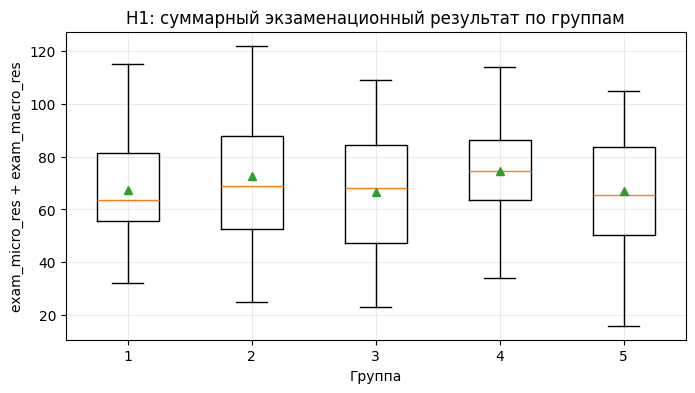

In [9]:
plt.figure(figsize=(8, 4))
values = [h1.loc[h1["group"] == g, "exam_sum_res"].dropna() for g in sorted(h1["group"].unique())]
plt.boxplot(values, labels=sorted(h1["group"].unique()), showmeans=True)
plt.title("H1: суммарный экзаменационный результат по группам")
plt.xlabel("Группа")
plt.ylabel("exam_micro_res + exam_macro_res")
plt.grid(alpha=0.25)
plt.show()


**Вывод H1.** Значимых различий между группами не найдено. Наблюдаемые отличия средних есть, но размер эффекта мал: группа объясняет около 2.3% вариации суммарного экзаменационного результата. Это хороший пример ситуации, где визуальные отличия не стоит интерпретировать без статистической проверки.


# 6. H2 — связь семестровой активности с экзаменом

**Метрика активности:** среднее между нормированной семинарской активностью и нормированным результатом летучек.  
**Основной критерий:** Spearman, потому что связь монотонная, не обязана быть линейной, а активность ограничена шкалой `0–1`.


In [10]:
h2_rows = []
for subject, act_col, exam_col in [
    ("Микроэкономика", "activity_micro", "exam_micro_res"),
    ("Макроэкономика", "activity_macro", "exam_macro_res"),
]:
    row = corr_row(df, act_col, exam_col, subject)
    h2_rows.append(row)

h2 = pd.DataFrame(h2_rows)
display(h2.round(4))

component_rows = []
for subject, sem_col, let_col, exam_col in [
    ("Микроэкономика", "sem_micro_norm", "let_micro_mean", "exam_micro_res"),
    ("Макроэкономика", "sem_macro_norm", "let_macro_mean", "exam_macro_res"),
]:
    component_rows.append(corr_row(df, sem_col, exam_col, f"{subject}: семинары"))
    temp = df.copy()
    temp[f"{let_col}_norm"] = temp[let_col] / 6
    component_rows.append(corr_row(temp, f"{let_col}_norm", exam_col, f"{subject}: летучки"))

components = pd.DataFrame(component_rows)
display(components.round(4))


,Показатель,N,Spearman rho,Spearman p,Pearson r,Pearson p,Kendall tau,Kendall p,Сила связи
0,Микроэкономика,149,0.5183,0.0000,0.4831,0.0000,0.3612,0.0000,сильная
1,Макроэкономика,142,0.5270,0.0000,0.5449,0.0000,0.3790,0.0000,сильная


,Показатель,N,Spearman rho,Spearman p,Pearson r,Pearson p,Kendall tau,Kendall p,Сила связи
0,Микроэкономика: семинары,149,0.4465,0.0000,0.4408,0.0000,0.3111,0.0000,умеренная
1,Микроэкономика: летучки,149,0.4509,0.0000,0.3976,0.0000,0.3079,0.0000,умеренная
2,Макроэкономика: семинары,142,0.5393,0.0000,0.5510,0.0000,0.3793,0.0000,сильная
3,Макроэкономика: летучки,142,0.3373,0.0000,0.3456,0.0000,0.2364,0.0000,умеренная


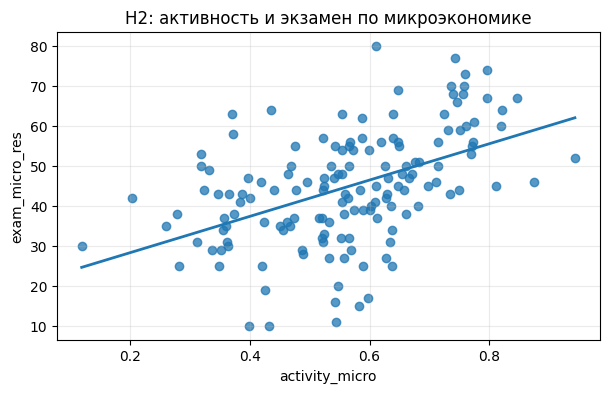

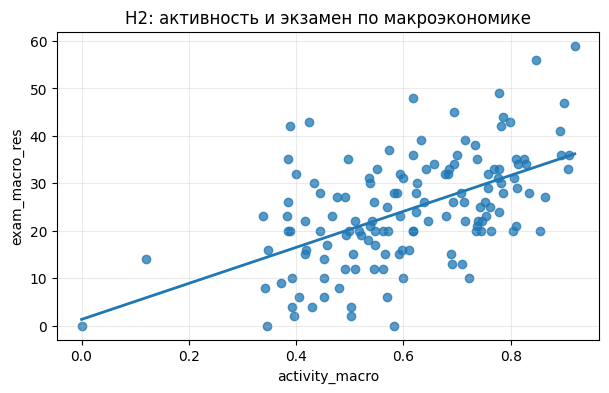

In [11]:
def scatter_with_line(data, x, y, title):
    pair = data[[x, y]].dropna()
    plt.figure(figsize=(7, 4))
    plt.scatter(pair[x], pair[y], alpha=0.75)
    if len(pair) >= 2:
        b1, b0 = np.polyfit(pair[x], pair[y], 1)
        xs = np.linspace(pair[x].min(), pair[x].max(), 100)
        plt.plot(xs, b1 * xs + b0, linewidth=2)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.25)
    plt.show()

scatter_with_line(df, "activity_micro", "exam_micro_res", "H2: активность и экзамен по микроэкономике")
scatter_with_line(df, "activity_macro", "exam_macro_res", "H2: активность и экзамен по макроэкономике")


**Вывод H2.** Активность статистически значимо связана с экзаменом по обоим предметам. Связь умеренная, а не детерминированная: активность повышает ожидаемый результат, но не гарантирует высокий экзаменационный балл.


# 7. H3 — согласованность результатов между микро- и макроэкономикой

Здесь проверяется, насколько поведение и результаты одного и того же студента устойчивы между двумя дисциплинами.


In [12]:
h3_specs = [
    ("Экзамены", "exam_micro_res", "exam_macro_res"),
    ("Итоговая активность", "activity_micro", "activity_macro"),
    ("Контрольные работы", "test_micro_avg", "test_macro_res"),
]

h3 = pd.DataFrame([corr_row(df, x, y, label) for label, x, y in h3_specs])
display(h3.round(4))


,Показатель,N,Spearman rho,Spearman p,Pearson r,Pearson p,Kendall tau,Kendall p,Сила связи
0,Экзамены,137,0.4849,0.0000,0.4624,0.0000,0.3425,0.0000,умеренная
1,Итоговая активность,152,0.6361,0.0000,0.6480,0.0000,0.4576,0.0000,сильная
2,Контрольные работы,129,0.6250,0.0000,0.6454,0.0000,0.4582,0.0000,сильная


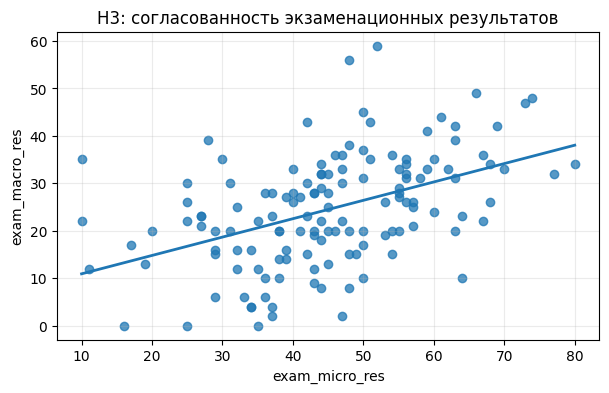

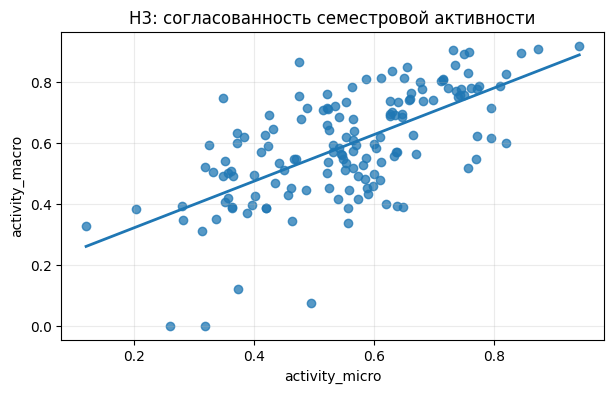

In [13]:
scatter_with_line(df, "exam_micro_res", "exam_macro_res", "H3: согласованность экзаменационных результатов")
scatter_with_line(df, "activity_micro", "activity_macro", "H3: согласованность семестровой активности")


**Вывод H3.** Между предметами есть устойчивая положительная связь. Самая сильная связь наблюдается не по экзаменам, а по учебному поведению и контрольным: регулярность работы студента лучше переносится между дисциплинами, чем итоговый экзаменационный результат.


# 8. H4 — связь образовательной скидки с экзаменационными результатами

`discount` рассматривается как порядковая переменная стартового академического уровня. Поэтому основной критерий — Spearman / Kendall, а ANOVA по уровням скидки используется как дополнительная проверка.


In [14]:
h4_rows = []
for subject, exam_col in [
    ("Микроэкономика", "exam_micro_res"),
    ("Макроэкономика", "exam_macro_res"),
]:
    h4_rows.append(corr_row(df, "discount", exam_col, subject))

h4_corr = pd.DataFrame(h4_rows)
display(h4_corr.round(4))

h4_grouped = df.groupby("discount").agg(
    n=("id", "count"),
    exam_micro_mean=("exam_micro_res", "mean"),
    exam_micro_median=("exam_micro_res", "median"),
    exam_macro_mean=("exam_macro_res", "mean"),
    exam_macro_median=("exam_macro_res", "median"),
).round(3)

display(h4_grouped)

anova_discount_rows = []
for subject, exam_col in [
    ("Микроэкономика", "exam_micro_res"),
    ("Макроэкономика", "exam_macro_res"),
]:
    temp = df[["discount", exam_col]].dropna()
    samples = [g[exam_col].values for _, g in temp.groupby("discount")]
    f_stat, p_val = stats.f_oneway(*samples)
    h_stat, p_kw = stats.kruskal(*samples)
    anova_discount_rows.append({"subject": subject, "ANOVA F": f_stat, "ANOVA p": p_val, "Kruskal H": h_stat, "Kruskal p": p_kw})

display(pd.DataFrame(anova_discount_rows).round(4))


,Показатель,N,Spearman rho,Spearman p,Pearson r,Pearson p,Kendall tau,Kendall p,Сила связи
0,Микроэкономика,128,0.3905,0.0000,0.3947,0.0000,0.2985,0.0000,умеренная
1,Макроэкономика,126,0.3134,0.0004,0.3186,0.0003,0.2366,0.0005,умеренная


,n,exam_micro_mean,exam_micro_median,exam_macro_mean,exam_macro_median
discount,,,,,
0.0000,15,32.7330,34.0000,18.4290,18.5000
25.0000,14,38.3570,38.0000,19.0770,20.0000
50.0000,34,45.4240,44.0000,21.3820,21.0000
75.0000,19,48.2780,47.0000,31.1110,28.5000
100.0000,51,49.7290,50.0000,27.5110,27.0000


,subject,ANOVA F,ANOVA p,Kruskal H,Kruskal p
0,Микроэкономика,6.3690,0.0001,22.3518,0.0002
1,Макроэкономика,4.9589,0.0010,16.6644,0.0022


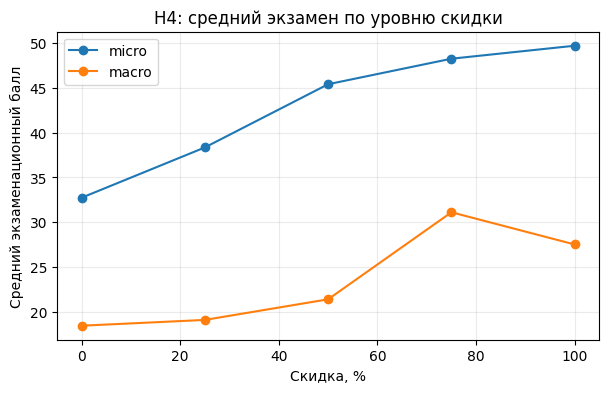

In [15]:
means = df.groupby("discount")[["exam_micro_res", "exam_macro_res"]].mean()

plt.figure(figsize=(7, 4))
plt.plot(means.index, means["exam_micro_res"], marker="o", label="micro")
plt.plot(means.index, means["exam_macro_res"], marker="o", label="macro")
plt.title("H4: средний экзамен по уровню скидки")
plt.xlabel("Скидка, %")
plt.ylabel("Средний экзаменационный балл")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


**Вывод H4.** Скидка положительно связана с результатами экзаменов, но сила связи умеренная и снижается от микроэкономики к макроэкономике. Это означает, что стартовый уровень важен, но не полностью определяет результат после обучения в течение года.


# 9. H5 — связь летучек и активности той же недели

Проверяется, являются ли летучка и аудиторная активность близкими метриками одной и той же вовлечённости. Поскольку проверок много, используется FDR-поправка.


In [16]:
df_h5 = df.copy()
for col in sem_micro_cols + sem_macro_cols:
    df_h5[col + "_norm"] = df_h5[col] / scale_by_teacher
for col in let_micro_cols + let_macro_cols:
    df_h5[col + "_norm"] = df_h5[col] / 6

weekly_rows = []
for subject, n_weeks in [("micro", min(len(sem_micro_cols), len(let_micro_cols))), ("macro", min(len(sem_macro_cols), len(let_macro_cols)))]:
    for week in range(1, n_weeks + 1):
        sem_col = f"sem_{subject}_{week}_norm"
        let_col = f"let_{subject}_{week}_norm"
        pair = df_h5[[sem_col, let_col]].dropna()
        if len(pair) >= 3 and pair[sem_col].nunique() > 1 and pair[let_col].nunique() > 1:
            rho, p = stats.spearmanr(pair[sem_col], pair[let_col])
            tau, pk = stats.kendalltau(pair[sem_col], pair[let_col])
            r, pp = stats.pearsonr(pair[sem_col], pair[let_col])
        else:
            rho = p = tau = pk = r = pp = np.nan
        weekly_rows.append({
            "subject": subject,
            "week": week,
            "N": len(pair),
            "Spearman rho": rho,
            "Spearman p": p,
            "Kendall tau": tau,
            "Pearson r": r,
        })

weekly = pd.DataFrame(weekly_rows)
weekly["Spearman p FDR"] = weekly.groupby("subject")["Spearman p"].transform(lambda x: benjamini_hochberg(x.values))
weekly["significant positive after FDR"] = (weekly["Spearman rho"] > 0) & (weekly["Spearman p FDR"] < ALPHA)

weekly_summary = weekly.groupby("subject").agg(
    weeks=("week", "count"),
    mean_rho=("Spearman rho", "mean"),
    median_rho=("Spearman rho", "median"),
    min_rho=("Spearman rho", "min"),
    max_rho=("Spearman rho", "max"),
    positive_weeks=("Spearman rho", lambda x: int((x > 0).sum())),
    significant_positive_weeks_fdr=("significant positive after FDR", "sum"),
).reset_index()

display(weekly.round(4))
display(weekly_summary.round(4))


,subject,week,N,Spearman rho,Spearman p,Kendall tau,Pearson r,Spearman p FDR,significant positive after FDR
0,micro,1,145,0.1638,0.0489,0.1332,0.1415,0.0598,False
1,micro,2,139,0.1832,0.0308,0.1484,0.1715,0.0485,True
2,micro,3,144,0.2682,0.0012,0.2056,0.2708,0.0032,True
3,micro,4,140,0.3075,0.0002,0.2518,0.3021,0.0012,True
4,micro,5,132,0.2285,0.0084,0.1747,0.1852,0.0154,True
5,micro,6,138,0.1295,0.1299,0.1075,0.1571,0.1299,False
6,micro,7,134,0.1561,0.0716,0.1343,0.1244,0.0788,False
7,micro,8,136,0.2934,0.0005,0.2580,0.2328,0.0019,True
8,micro,9,126,0.1819,0.0415,0.1461,0.0681,0.0571,False
9,micro,10,142,0.3447,0.0000,0.2725,0.2684,0.0003,True


,subject,weeks,mean_rho,median_rho,min_rho,max_rho,positive_weeks,significant_positive_weeks_fdr
0,macro,15,0.2050,0.2303,-0.2384,0.5084,13,12
1,micro,11,0.2256,0.2245,0.1295,0.3447,11,7


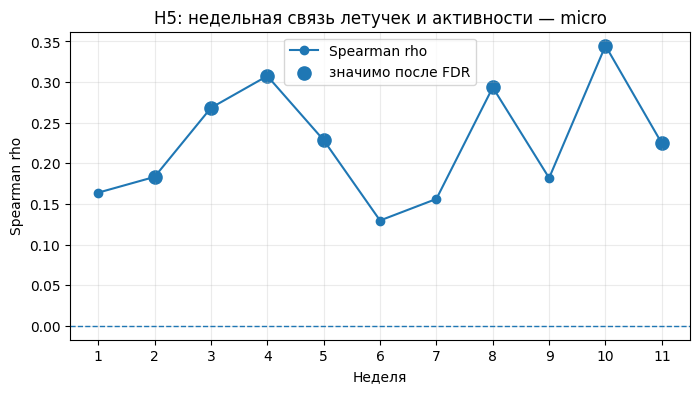

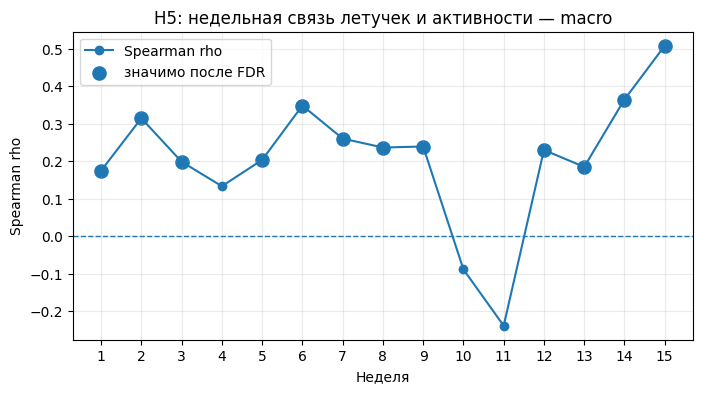

In [17]:
for subject in ["micro", "macro"]:
    sub = weekly[weekly["subject"] == subject]
    plt.figure(figsize=(8, 4))
    plt.plot(sub["week"], sub["Spearman rho"], marker="o", label="Spearman rho")
    significant = sub[sub["significant positive after FDR"]]
    plt.scatter(significant["week"], significant["Spearman rho"], s=90, label="значимо после FDR")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"H5: недельная связь летучек и активности — {subject}")
    plt.xlabel("Неделя")
    plt.ylabel("Spearman rho")
    plt.xticks(sub["week"])
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


**Вывод H5.** Связь чаще положительная, но слабая. Летучки и активность одной недели не стоит считать взаимозаменяемыми показателями: летучка фиксирует подготовку / присутствие, а активность — поведение на семинаре.


# 10. Финальная интерпретация

## Главные выводы

1. **Группа и преподаватель не показали статистически значимого эффекта** на суммарный экзаменационный результат. Визуальные различия между группами есть, но они не проходят проверку на значимость.
2. **Семестровая активность — самый устойчивый фактор**, связанный с экзаменами по обоим предметам.
3. **Результаты между предметами согласованы**, особенно по учебному поведению и контрольным работам.
4. **Стартовый уровень подготовки связан с результатом**, но эта связь не определяющая и ослабевает во втором семестре.
5. **Летучки и аудиторная активность связаны, но измеряют разные аспекты поведения.**

## Что важно в методологии

- Для каждого вопроса выбран отдельный критерий, а не один универсальный тест.
- Перед ANOVA проверены предпосылки: нормальность и равенство дисперсий.
- Для порядковых и ограниченных метрик использованы ранговые методы.
- Для множественных недельных тестов применена FDR-поправка.
- Выводы строятся не только по `p-value`, но и по размеру эффекта / силе связи.


# 11. Ограничения анализа

| Ограничение | Почему важно |
|---|---|
| Наблюдательное исследование | корреляции не доказывают причинность |
| Группа и преподаватель частично смешаны | сложно полностью отделить эффект группы от эффекта преподавателя |
| Пропуски не случайны с гарантией | неявка на экзамен или контрольную может быть связана с успеваемостью |
| Метрика скидки грубая | 5 уровней скидки не передают все различия стартовой подготовки |
| Активность зависит от шкалы преподавателя | нормализация снижает проблему, но не устраняет различия в критериях оценивания полностью |
